# ResNet — Fase 2
Pipeline por modelo:
- **Fase A** — Grid search: LR × Dropout × Weighted loss (18 runs × 10 epochs)
- **Fase B** — Ablation: Fine-tuning, Scheduler, CutMix, Label Smoothing (com hiperparâmetros da Fase A se melhoraram, senão originais)
- **Modelo final** — melhores hiperparâmetros + melhor entre combinação e melhor individual
- **Ensemble** dos 3 modelos finais

NOTAS:
1. Se a Fase A (grid) não superar o baseline → usa os hiperparâmetros originais da fase 1
2. Modelo final = melhor entre (combinação das técnicas seleccionadas) e (melhor modelo individual do ablation)

![Phase 1 Pipeline](../outputs/figures/phase2_pipeline.png)

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys
import copy
import time
import random
import warnings
from itertools import product

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)


sys.path.append(os.path.abspath("../src"))
from dataset import ButterflyDataset
from transforms import get_transforms

os.makedirs("../outputs/figures",     exist_ok=True)
os.makedirs("../outputs/results",     exist_ok=True)
os.makedirs("../outputs/submissions", exist_ok=True)
os.makedirs("../outputs/models",      exist_ok=True)

print("Setup completo.")

/Users/ritapduarte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
Setup completo.


In [ ]:
# ── Dataset ──
path = kagglehub.competition_download('aca-butterflies')
competition_dir = path
train_dir = os.path.join(competition_dir, "train")
test_dir  = os.path.join(competition_dir, "test")
train_csv = os.path.join(competition_dir, "train.csv")


SAMPLE_SUBMISSION_PATH = "../exemplo/submission.csv"

df = pd.read_csv(train_csv)
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

classes      = sorted(df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)

train_df["label_idx"] = train_df["label"].map(class_to_idx).astype(int)
val_df["label_idx"]   = val_df["label"].map(class_to_idx).astype(int)

train_transform, val_transform, test_transform = get_transforms()

BATCH_SIZE    = 32
train_dataset = ButterflyDataset(train_df, train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(val_df,   train_dir, transform=val_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Class weights para weighted loss
class_counts  = train_df["label_idx"].value_counts().sort_index()
class_weights = len(train_df) / (NUM_CLASSES * class_counts.values)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {NUM_CLASSES}")
print(f"Class weights — min: {class_weights.min():.3f} | max: {class_weights.max():.3f}")

Train: 4159 | Val: 1040 | Classes: 75
Class weights — min: 0.660 | max: 1.206


In [ ]:
# ── Funções auxiliares ──
def build_model(arch, num_classes, dropout_p=0.0):
    weights_map = {
        "resnet18": models.ResNet18_Weights.IMAGENET1K_V1,
        "resnet34": models.ResNet34_Weights.IMAGENET1K_V1,
        "resnet50": models.ResNet50_Weights.IMAGENET1K_V2,
    }
    model_fn_map = {
        "resnet18": models.resnet18,
        "resnet34": models.resnet34,
        "resnet50": models.resnet50,
    }
    model       = model_fn_map[arch](weights=weights_map[arch])
    in_features = model.fc.in_features
    if dropout_p > 0.0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    return model


def get_criterion(loss_name, label_smoothing=0.0, weight=None):
    if loss_name == "CrossEntropyLoss":
        return nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=weight)
    elif loss_name == "MultiMarginLoss":
        return nn.MultiMarginLoss(weight=weight)
    raise ValueError(f"Loss '{loss_name}' nao suportada.")


def get_optimizer(opt_name, params, lr, weight_decay=1e-4):
    if opt_name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == "RMSprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    raise ValueError(f"Optimizador '{opt_name}' nao suportado.")


def cutmix_data(images, labels, alpha=1.0):
    lam          = np.random.beta(alpha, alpha)
    rand_index   = torch.randperm(images.size(0)).to(images.device)
    labels_a     = labels
    labels_b     = labels[rand_index]
    _, _, H, W   = images.shape
    cut_ratio    = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy       = np.random.randint(W), np.random.randint(H)
    x1, x2      = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2      = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    images_mixed = images.clone()
    images_mixed[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]
    lam = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return images_mixed, labels_a, labels_b, lam


def train_epoch(model, loader, criterion, optimizer, device, use_cutmix=False):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        if use_cutmix and np.random.rand() < 0.5:
            images, labels_a, labels_b, lam = cutmix_data(images, labels)
            outputs = model(images)
            loss    = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            all_labels.extend(labels_a.cpu().numpy())
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            all_labels.extend(labels.cpu().numpy())
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            running_loss  += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))


def train_model(model, criterion, optimizer, train_loader, val_loader,
                device, num_epochs=20, patience=5, scheduler=None,
                use_cutmix=False, label="run"):
    history = {k: [] for k in ["train_loss","val_loss","train_acc","val_acc","train_f1","val_f1"]}
    best_val_acc, best_weights, patience_count = 0.0, None, 0
    t_start = time.time()
    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc, t_f1 = train_epoch(model, train_loader, criterion, optimizer, device, use_cutmix)
        v_loss, v_acc, v_f1 = val_epoch(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step()
        for k, v in zip(history.keys(), [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1]):
            history[k].append(v)
        print(f"  [{label}] Epoch {epoch:02d}/{num_epochs} "
              f"| Val acc {v_acc:.4f}  F1 {v_f1:.4f}  Loss {v_loss:.4f}")
        if v_acc > best_val_acc:
            best_val_acc   = v_acc
            best_weights   = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping na epoch {epoch}.")
                break
    model.load_state_dict(best_weights)
    best_f1 = max(history["val_f1"])
    print(f"  Melhor val acc: {best_val_acc:.4f} | Tempo: {time.time()-t_start:.1f}s")
    return model, history, best_val_acc, best_f1


def freeze_backbone(model):
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False

def unfreeze_layer(model, layer_name):
    for name, param in model.named_parameters():
        if layer_name in name:
            param.requires_grad = True


def generate_submission(model, sample_submission_path, test_dir,
                        transform, idx_to_class, device,
                        batch_size=32, output_path=None, tta_transforms=None):
    sample_df = pd.read_csv(sample_submission_path)
    test_df   = pd.DataFrame({"filename": sample_df["filename"]})
    model.eval()
    transforms_list       = tta_transforms if tta_transforms else [transform]
    all_probs, fnames_out = None, None
    for tfm in transforms_list:
        dataset    = ButterflyDataset(test_df, test_dir, transform=tfm, is_test=True)
        loader     = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        probs_list, fnames_list = [], []
        with torch.no_grad():
            for images, fnames in loader:
                probs = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
                probs_list.append(probs)
                fnames_list.extend(fnames)
        probs_arr = np.vstack(probs_list)
        if all_probs is None:
            all_probs, fnames_out = probs_arr, fnames_list
        else:
            all_probs += probs_arr
    avg_probs = all_probs / len(transforms_list)
    preds     = avg_probs.argmax(axis=1)
    sub       = pd.DataFrame({
        "filename": fnames_out,
        "label":    [idx_to_class[p] for p in preds]
    })
    if output_path:
        sub.to_csv(output_path, index=False)
        print(f"  Submission guardada: {output_path} ({len(sub)} linhas)")
    return sub, avg_probs, fnames_out


print("Funcoes auxiliares carregadas.")

Funcoes auxiliares carregadas.


In [ ]:
# ── Configuração ──
TOP3 = [
    {"arch": "resnet18", "loss": "CrossEntropyLoss", "optimizer": "Adam",
     "baseline_acc": 0.9548, "baseline_f1": 0.9560, "id": "resnet18_CE_Adam",
     "default_lr": 1e-4},
    {"arch": "resnet50", "loss": "CrossEntropyLoss", "optimizer": "Adam",
     "baseline_acc": 0.9462, "baseline_f1": 0.9471, "id": "resnet50_CE_Adam",
     "default_lr": 1e-4},
    {"arch": "resnet50", "loss": "MultiMarginLoss",  "optimizer": "Adam",
     "baseline_acc": 0.9423, "baseline_f1": 0.9427, "id": "resnet50_MM_Adam",
     "default_lr": 1e-4},
]

# Fase A: grid
LR_GRID       = [1e-3, 1e-4, 1e-5]
DROPOUT_GRID  = [0.0, 0.2, 0.3]
WEIGHTED_GRID = [False, True]
NUM_EPOCHS_GRID = 10
PATIENCE_GRID   = 4

# Fase B: ablation
NUM_EPOCHS_ABL = 20
PATIENCE_ABL   = 5

IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
TTA_TRANSFORMS = [
    T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256,256)), T.CenterCrop(224), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize((256,256)), T.CenterCrop(224), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

total_grid = len(LR_GRID) * len(DROPOUT_GRID) * len(WEIGHTED_GRID)
print(f"Grid fase A: {total_grid} runs por modelo x 3 modelos = {total_grid*3} runs totais")

Grid fase A: 18 runs por modelo x 3 modelos = 54 runs totais


In [ ]:
# ── Pipeline principal ───
all_ablation_rows = []
final_models      = []
final_probs_list  = []
filenames_test    = None

for cfg in TOP3:
    arch         = cfg["arch"]
    loss_name    = cfg["loss"]
    opt_name     = cfg["optimizer"]
    baseline     = cfg["baseline_acc"]
    model_id     = cfg["id"]
    default_lr   = cfg["default_lr"]

    print(f"\n{'#'*65}")
    print(f"  MODELO: {model_id}  (baseline fase 1: {baseline:.4f})")
    print(f"{'#'*65}")

    ablation_row = {"Modelo": model_id, "Baseline fase 1": baseline}

    # ══════════════════════════════════════════════════════════════════════════
    # FASE A — Grid search: LR x Dropout x Weighted loss
    # ══════════════════════════════════════════════════════════════════════════
    print("\n== FASE A: Grid search de hiperparametros ==")
    grid_results = []
    total_grid   = len(LR_GRID) * len(DROPOUT_GRID) * len(WEIGHTED_GRID)
    run_num      = 0

    for lr, dp, use_w in product(LR_GRID, DROPOUT_GRID, WEIGHTED_GRID):
        run_num += 1
        print(f"\n  [{run_num}/{total_grid}] LR={lr} | Dropout={dp} | Weighted={use_w}")
        m  = build_model(arch, NUM_CLASSES, dropout_p=dp).to(device)
        cr = get_criterion(loss_name, weight=class_weights if use_w else None)
        op = get_optimizer(opt_name, m.parameters(), lr=lr)
        _, _, acc, f1 = train_model(
            m, cr, op, train_loader, val_loader, device,
            num_epochs=NUM_EPOCHS_GRID, patience=PATIENCE_GRID,
            label=f"lr={lr}_dp={dp}_w={use_w}"
        )
        grid_results.append({"lr": lr, "dropout": dp, "weighted": use_w,
                              "val_acc": acc, "val_f1": f1})

    best_hp = max(grid_results, key=lambda x: x["val_acc"])
    grid_df = pd.DataFrame(grid_results).sort_values("val_acc", ascending=False)
    grid_df.to_csv(f"../outputs/results/grid_search_{model_id}.csv", index=False)
    ablation_row["Grid best acc"] = round(best_hp["val_acc"], 4)

    # se o grid não superar o baseline, usa hiperparâmetros originais
    if best_hp["val_acc"] > baseline:
        BEST_LR       = best_hp["lr"]
        BEST_DROPOUT  = best_hp["dropout"]
        BEST_WEIGHTED = best_hp["weighted"]
        print(f"\n  Grid melhorou baseline ({best_hp['val_acc']:.4f} > {baseline:.4f})")
        print(f"  A usar hiperparametros do grid: LR={BEST_LR} | Dropout={BEST_DROPOUT} | Weighted={BEST_WEIGHTED}")
        ablation_row["Hiperparametros fonte"] = "grid"
    else:
        BEST_LR       = default_lr
        BEST_DROPOUT  = 0.0
        BEST_WEIGHTED = False
        print(f"\n  Grid nao melhorou baseline ({best_hp['val_acc']:.4f} <= {baseline:.4f})")
        print(f"  A usar hiperparametros originais: LR={BEST_LR} | Dropout=0.0 | Weighted=False")
        ablation_row["Hiperparametros fonte"] = "fase_1_originais"

    ablation_row["LR usado"]       = BEST_LR
    ablation_row["Dropout usado"]  = BEST_DROPOUT
    ablation_row["Weighted usado"] = BEST_WEIGHTED

    # ══════════════════════════════════════════════════════════════════════════
    # FASE B — Ablation com os hiperparâmetros decididos acima
    # ══════════════════════════════════════════════════════════════════════════
    print("\n== FASE B: Ablation das tecnicas ==")
    tecnicas = {}

    # dicionário mutável em vez de variáveis com nonlocal (não resultou antes)
    best_individual = {"acc": baseline, "model": None, "name": "baseline_fase_1"}

    def supera(acc):
        return acc > baseline

    def base_model():
        return build_model(arch, NUM_CLASSES, dropout_p=BEST_DROPOUT).to(device)

    def base_criterion(smoothing=0.0):
        return get_criterion(
            loss_name,
            label_smoothing=smoothing,
            weight=class_weights if BEST_WEIGHTED else None
        )

    def base_optimizer(model):
        return get_optimizer(opt_name, model.parameters(), lr=BEST_LR)

    def base_scheduler(optimizer):
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS_ABL, eta_min=1e-6
        )

    def update_best_individual(model, acc, name):
        if acc > best_individual["acc"]:
            best_individual["acc"]   = acc
            best_individual["model"] = copy.deepcopy(model)
            best_individual["name"]  = name
            print(f"    Novo melhor individual: {name} ({acc:.4f})")

    # B1: Fine-tuning gradual
    print("\n--- B1: Fine-tuning gradual ---")
    model_ft = base_model()
    cr_ft    = base_criterion()
    freeze_backbone(model_ft)
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR)
    model_ft, _, _, _ = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                     num_epochs=5, patience=5, label="ft_A")
    unfreeze_layer(model_ft, "layer4")
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR/5)
    model_ft, _, _, _ = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                     num_epochs=5, patience=5, label="ft_B")
    unfreeze_layer(model_ft, "layer3")
    op = get_optimizer(opt_name, filter(lambda p: p.requires_grad, model_ft.parameters()), lr=BEST_LR/10)
    model_ft, _, ft_acc, _ = train_model(model_ft, cr_ft, op, train_loader, val_loader, device,
                                          num_epochs=5, patience=5, label="ft_C")
    tecnicas["fine_tuning"] = supera(ft_acc)
    ablation_row["Fine-tuning acc"] = round(ft_acc, 4)
    print(f"  Fine-tuning: {ft_acc:.4f} {'v seleccionado' if supera(ft_acc) else 'x descartado'}")
    if supera(ft_acc):
        update_best_individual(model_ft, ft_acc, "fine_tuning")

    # B2: CosineAnnealingLR
    print("\n--- B2: CosineAnnealingLR ---")
    model_sc = base_model()
    cr_sc    = base_criterion()
    op       = base_optimizer(model_sc)
    sched    = base_scheduler(op)
    _, _, sc_acc, _ = train_model(model_sc, cr_sc, op, train_loader, val_loader, device,
                                   num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE_ABL,
                                   scheduler=sched, label="cosine")
    tecnicas["scheduler"] = supera(sc_acc)
    ablation_row["Scheduler acc"] = round(sc_acc, 4)
    print(f"  Scheduler: {sc_acc:.4f} {'v seleccionado' if supera(sc_acc) else 'x descartado'}")
    if supera(sc_acc):
        update_best_individual(model_sc, sc_acc, "scheduler")

    # B3: CutMix
    print("\n--- B3: CutMix ---")
    model_cm = base_model()
    cr_cm    = base_criterion()
    op       = base_optimizer(model_cm)
    sched    = base_scheduler(op)
    _, _, cm_acc, _ = train_model(model_cm, cr_cm, op, train_loader, val_loader, device,
                                   num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE_ABL,
                                   scheduler=sched, use_cutmix=True, label="cutmix")
    tecnicas["cutmix"] = supera(cm_acc)
    ablation_row["CutMix acc"] = round(cm_acc, 4)
    print(f"  CutMix: {cm_acc:.4f} {'v seleccionado' if supera(cm_acc) else 'x descartado'}")
    if supera(cm_acc):
        update_best_individual(model_cm, cm_acc, "cutmix")

    # B4: Label Smoothing (só CrossEntropy)
    if loss_name == "CrossEntropyLoss":
        print("\n--- B4: Label Smoothing ---")
        model_ls = base_model()
        cr_ls    = base_criterion(smoothing=0.1)
        op       = base_optimizer(model_ls)
        sched    = base_scheduler(op)
        _, _, ls_acc, _ = train_model(model_ls, cr_ls, op, train_loader, val_loader, device,
                                       num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE_ABL,
                                       scheduler=sched, use_cutmix=True, label="label_smooth")
        tecnicas["label_smoothing"] = supera(ls_acc)
        ablation_row["Label Smoothing acc"] = round(ls_acc, 4)
        print(f"  Label Smoothing: {ls_acc:.4f} {'v seleccionado' if supera(ls_acc) else 'x descartado'}")
        if supera(ls_acc):
            update_best_individual(model_ls, ls_acc, "label_smoothing")
    else:
        tecnicas["label_smoothing"] = False
        ablation_row["Label Smoothing acc"] = "N/A"

    # ══════════════════════════════════════════════════════════════════════════
    # MODELO COMBINADO FINAL
    # ══════════════════════════════════════════════════════════════════════════
    seleccionadas = [k for k, v in tecnicas.items() if v]
    print(f"\n== Modelo combinado: {model_id} ==")
    print(f"  Tecnicas seleccionadas: {seleccionadas}")

    if len(seleccionadas) > 1:
        use_smoothing = tecnicas.get("label_smoothing", False) and loss_name == "CrossEntropyLoss"
        use_cutmix_f  = tecnicas.get("cutmix", False)
        use_scheduler = tecnicas.get("scheduler", False)

        model_comb = base_model()
        cr_comb    = base_criterion(smoothing=0.1 if use_smoothing else 0.0)
        op_comb    = base_optimizer(model_comb)
        sched_comb = base_scheduler(op_comb) if use_scheduler else None

        _, _, comb_acc, comb_f1 = train_model(
            model_comb, cr_comb, op_comb, train_loader, val_loader, device,
            num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE_ABL,
            scheduler=sched_comb, use_cutmix=use_cutmix_f,
            label=f"{model_id}_combinado"
        )
        ablation_row["Combinado acc"] = round(comb_acc, 4)

        # escolhe entre combinado e melhor individual
        if best_individual["model"] is not None and best_individual["acc"] >= comb_acc:
            print(f"\n  Melhor individual '{best_individual['name']}' ({best_individual['acc']:.4f})"
                  f" >= combinado ({comb_acc:.4f})")
            print(f"  A usar melhor modelo individual como modelo final")
            model_final = best_individual["model"]
            final_acc   = best_individual["acc"]
            ablation_row["Modelo final fonte"] = f"individual ({best_individual['name']})"
        else:
            print(f"\n  Combinado ({comb_acc:.4f}) > melhor individual ({best_individual['acc']:.4f})")
            print(f"  A usar modelo combinado como modelo final")
            model_final = model_comb
            final_acc   = comb_acc
            ablation_row["Modelo final fonte"] = "combinado"

    elif len(seleccionadas) == 1:
        print(f"  Apenas 1 tecnica — a usar melhor individual ({best_individual['name']})")
        model_final = best_individual["model"]
        final_acc   = best_individual["acc"]
        ablation_row["Combinado acc"]      = "N/A (1 tecnica)"
        ablation_row["Modelo final fonte"] = f"individual ({best_individual['name']})"

    else:
        print(f"  Nenhuma tecnica seleccionada — a re-treinar com hiperparametros base")
        model_final = base_model()
        cr_base     = base_criterion()
        op_base     = base_optimizer(model_final)
        _, _, final_acc, _ = train_model(
            model_final, cr_base, op_base, train_loader, val_loader, device,
            num_epochs=NUM_EPOCHS_ABL, patience=PATIENCE_ABL,
            label=f"{model_id}_base"
        )
        ablation_row["Combinado acc"]      = "N/A (0 tecnicas)"
        ablation_row["Modelo final fonte"] = "baseline_re-treino"

    # Avaliar modelo final
    cr_eval = get_criterion(loss_name)
    _, final_acc_eval, final_f1_eval = val_epoch(model_final, val_loader, cr_eval, device)

    ablation_row["Modelo final acc"]  = round(final_acc_eval, 4)
    ablation_row["Modelo final F1"]   = round(final_f1_eval, 4)
    ablation_row["Ganho vs baseline"] = round(final_acc_eval - baseline, 4)
    all_ablation_rows.append(ablation_row)

    torch.save(model_final.state_dict(), f"../outputs/models/{model_id}_final.pth")

    print(f"\n  A gerar submission individual para {model_id}...")
    sub, test_probs, test_fnames = generate_submission(
        model_final, SAMPLE_SUBMISSION_PATH, test_dir,
        test_transform, idx_to_class, device,
        output_path=f"../outputs/submissions/submission_{model_id}_final.csv",
        tta_transforms=TTA_TRANSFORMS
    )

    final_models.append(model_final)
    final_probs_list.append(test_probs)
    if filenames_test is None:
        filenames_test = test_fnames

    print(f"\n  {model_id} concluido")
    print(f"    Modelo final acc : {final_acc_eval:.4f}")
    print(f"    Modelo final F1  : {final_f1_eval:.4f}")
    print(f"    Ganho vs baseline: {final_acc_eval - baseline:+.4f}")

print("\n" + "="*65)
print("Pipeline completo para os 3 modelos.")


#################################################################
  MODELO: resnet18_CE_Adam  (baseline fase 1: 0.9548)
#################################################################

== FASE A: Grid search de hiperparametros ==

  [1/18] LR=0.001 | Dropout=0.0 | Weighted=False
  [lr=0.001_dp=0.0_w=False] Epoch 01/10 | Val acc 0.5106  F1 0.4940  Loss 1.8594
  [lr=0.001_dp=0.0_w=False] Epoch 02/10 | Val acc 0.6827  F1 0.6765  Loss 1.0295
  [lr=0.001_dp=0.0_w=False] Epoch 03/10 | Val acc 0.7413  F1 0.7342  Loss 0.9384
  [lr=0.001_dp=0.0_w=False] Epoch 04/10 | Val acc 0.7221  F1 0.7135  Loss 0.9816
  [lr=0.001_dp=0.0_w=False] Epoch 05/10 | Val acc 0.8346  F1 0.8297  Loss 0.5308
  [lr=0.001_dp=0.0_w=False] Epoch 06/10 | Val acc 0.6375  F1 0.6415  Loss 1.5827
  [lr=0.001_dp=0.0_w=False] Epoch 07/10 | Val acc 0.8288  F1 0.8264  Loss 0.6144
  [lr=0.001_dp=0.0_w=False] Epoch 08/10 | Val acc 0.8231  F1 0.8210  Loss 0.6173
  [lr=0.001_dp=0.0_w=False] Epoch 09/10 | Val acc 0.8192  F1 0.8090  

In [6]:
# ── Tabela de ablation study completa ─────────────────────────────────────────
ablation_df = pd.DataFrame(all_ablation_rows)
print(ablation_df.to_string(index=False))
ablation_df.to_csv("../outputs/results/ablation_study_top3.csv", index=False)
print("\nTabela guardada em ../outputs/results/ablation_study_top3.csv")

          Modelo  Baseline fase 1  Grid best acc Hiperparametros fonte  LR usado  Dropout usado  Weighted usado  Fine-tuning acc  Scheduler acc  CutMix acc Label Smoothing acc    Combinado acc  Modelo final fonte  Modelo final acc  Modelo final F1  Ganho vs baseline
resnet18_CE_Adam           0.9548         0.9442      fase_1_originais    0.0001            0.0           False           0.9192         0.9500      0.9490                0.95 N/A (0 tecnicas)  baseline_re-treino            0.9471           0.9487            -0.0077
resnet50_CE_Adam           0.9462         0.9519                  grid    0.0001            0.3           False           0.9212         0.9510      0.9615              0.9587           0.9577 individual (cutmix)            0.9615           0.9624             0.0153
resnet50_MM_Adam           0.9423         0.9433                  grid    0.0001            0.3            True           0.8971         0.9337      0.9337                 N/A N/A (0 tecnicas)  basel

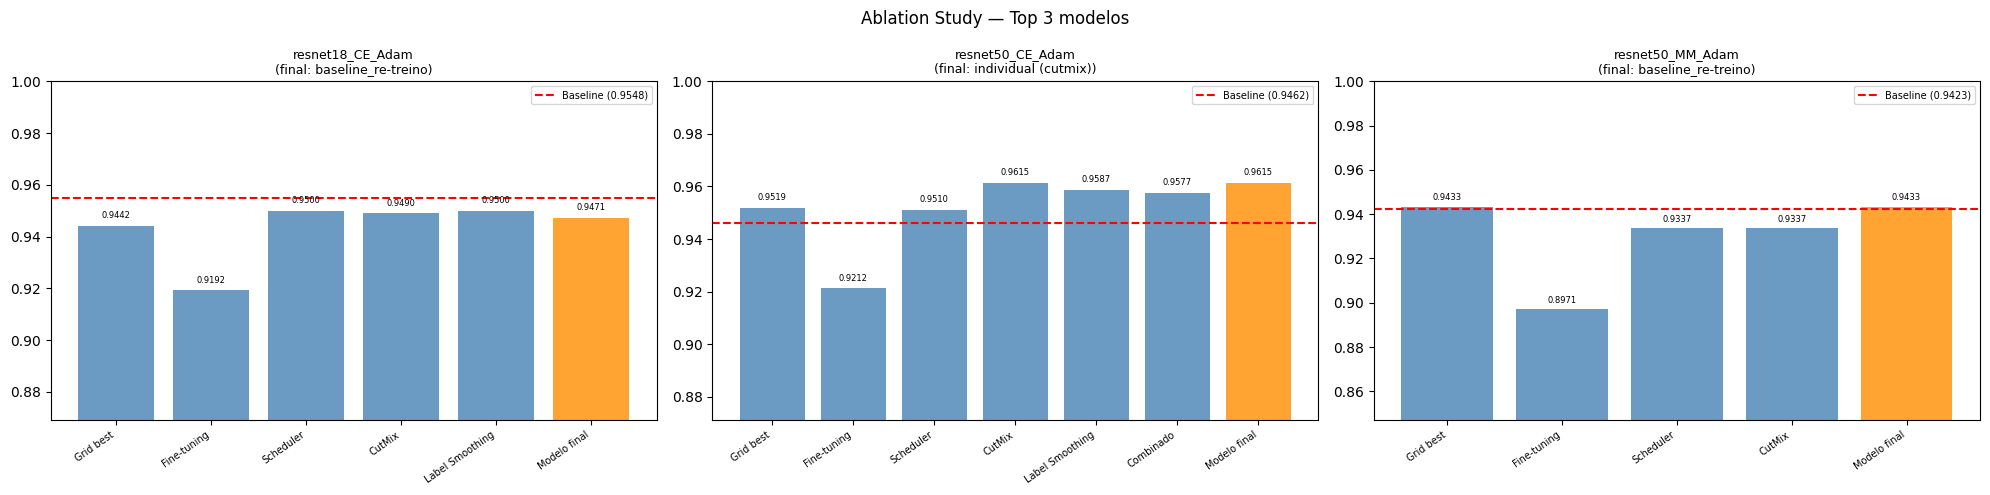

In [ ]:
# ── Gráfico ablation por modelo ───
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metrics   = ["Grid best acc", "Fine-tuning acc", "Scheduler acc",
             "CutMix acc", "Label Smoothing acc", "Combinado acc", "Modelo final acc"]

for ax, row in zip(axes, all_ablation_rows):
    vals, labels = [], []
    for m in metrics:
        v = row.get(m)
        if v is not None and v not in ["N/A", "N/A (1 tecnica)", "N/A (0 tecnicas)"]:
            vals.append(float(v))
            labels.append(m.replace(" acc", ""))
    baseline = row["Baseline fase 1"]
    colors   = ["steelblue" if l != "Modelo final" else "darkorange" for l in labels]
    bars     = ax.bar(labels, vals, color=colors, alpha=0.8)
    ax.axhline(y=baseline, color="red", linestyle="--",
               linewidth=1.5, label=f"Baseline ({baseline:.4f})")
    ax.set_title(f"{row['Modelo']}\n(final: {row['Modelo final fonte']})", fontsize=9)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.0)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7)
    ax.legend(fontsize=7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", fontsize=6)

plt.suptitle("Ablation Study — Top 3 modelos", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/ablation_top3.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Ensemble dos 3 modelos finais ───
print("A construir ensemble dos 3 modelos finais...")

for m in final_models:
    m.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs  = sum(
            torch.softmax(m(images), dim=1) for m in final_models
        ) / len(final_models)
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

ens_acc = accuracy_score(all_labels, all_preds)
ens_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"\nEnsemble val — Acc: {ens_acc:.4f} | Macro F1: {ens_f1:.4f}")

avg_probs_ens = sum(final_probs_list) / len(final_probs_list)
preds_ens     = avg_probs_ens.argmax(axis=1)

submission_ens = pd.DataFrame({
    "filename": filenames_test,
    "label":    [idx_to_class[p] for p in preds_ens]
})
submission_ens.to_csv("../outputs/submissions/submission_ensemble_fase2final_top3modelos.csv", index=False)
print(f"Submission ensemble guardada ({len(submission_ens)} linhas)")
submission_ens.head()

A construir ensemble dos 3 modelos finais...

Ensemble val — Acc: 0.9596 | Macro F1: 0.9604
Submission ensemble guardada (1300 linhas)


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_2.jpg,ZEBRA LONG WING
3,Image_3.jpg,COMMON BANDED AWL
4,Image_4.jpg,PAPER KITE


In [ ]:
# ── Resumo final ───
print("\n" + "="*65)
print("RESUMO FINAL")
print("="*65)
for row in all_ablation_rows:
    print(f"  {row['Modelo']}")
    print(f"    Baseline fase 1      : {row['Baseline fase 1']:.4f}")
    print(f"    Grid best acc        : {row['Grid best acc']:.4f} ({row['Hiperparametros fonte']})")
    print(f"    Hiperparametros usados: LR={row['LR usado']} | Dropout={row['Dropout usado']} | Weighted={row['Weighted usado']}")
    print(f"    Modelo final acc     : {row['Modelo final acc']:.4f} ({row['Modelo final fonte']})")
    print(f"    Modelo final F1      : {row['Modelo final F1']:.4f}")
    print(f"    Ganho vs baseline    : {row['Ganho vs baseline']:+.4f}")
    print()
print(f"Ensemble final — Val Acc: {ens_acc:.4f} | Val F1: {ens_f1:.4f}")
print("\nSubmissions geradas:")
for cfg in TOP3:
    print(f"  ../outputs/submissions/submission_{cfg['id']}_final.csv")
print("  ../outputs/submissions/submission_ensemble_fase2final_top3modelos.csv")


RESUMO FINAL
  resnet18_CE_Adam
    Baseline fase 1      : 0.9548
    Grid best acc        : 0.9442 (fase_1_originais)
    Hiperparametros usados: LR=0.0001 | Dropout=0.0 | Weighted=False
    Modelo final acc     : 0.9471 (baseline_re-treino)
    Modelo final F1      : 0.9487
    Ganho vs baseline    : -0.0077

  resnet50_CE_Adam
    Baseline fase 1      : 0.9462
    Grid best acc        : 0.9519 (grid)
    Hiperparametros usados: LR=0.0001 | Dropout=0.3 | Weighted=False
    Modelo final acc     : 0.9615 (individual (cutmix))
    Modelo final F1      : 0.9624
    Ganho vs baseline    : +0.0153

  resnet50_MM_Adam
    Baseline fase 1      : 0.9423
    Grid best acc        : 0.9433 (grid)
    Hiperparametros usados: LR=0.0001 | Dropout=0.3 | Weighted=True
    Modelo final acc     : 0.9433 (baseline_re-treino)
    Modelo final F1      : 0.9442
    Ganho vs baseline    : +0.0010

Ensemble final — Val Acc: 0.9596 | Val F1: 0.9604

Submissions geradas:
  ../outputs/submissions/submission_re

In [ ]:
# ── Ensemble final: resnet18 (fase 1) + resnet50_CE_Adam (fase 2) ──

# Carregar resnet18 da fase 1
model_p1 = build_model("resnet18", NUM_CLASSES, dropout_p=0.0).to(device)
model_p1.load_state_dict(torch.load("../outputs/models/best_resnet.pth", map_location=device))
model_p1.eval()

# Carregar resnet50_CE_Adam da fase 2 (dropout=0.3 conforme hiperparâmetros usados)
model_p2 = build_model("resnet50", NUM_CLASSES, dropout_p=0.3).to(device)
model_p2.load_state_dict(torch.load("../outputs/models/resnet50_CE_Adam_final.pth", map_location=device))
model_p2.eval()

ensemble_final = [model_p1, model_p2]

# Avaliar no val set
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        probs  = sum(
            torch.softmax(m(images), dim=1) for m in ensemble_final
        ) / len(ensemble_final)
        all_preds.extend(probs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

ens_acc = accuracy_score(all_labels, all_preds)
ens_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"Ensemble final val — Acc: {ens_acc:.4f} | Macro F1: {ens_f1:.4f}")

# Gerar submission com TTA
all_probs, fnames_out = None, None
sample_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)
test_df_ens = pd.DataFrame({"filename": sample_df["filename"]})

for tfm in TTA_TRANSFORMS:
    dataset    = ButterflyDataset(test_df_ens, test_dir, transform=tfm, is_test=True)
    loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    probs_list, fnames_list = [], []
    with torch.no_grad():
        for images, fnames in loader:
            images = images.to(device)
            probs  = sum(
                torch.softmax(m(images), dim=1) for m in ensemble_final
            ) / len(ensemble_final)
            probs_list.append(probs.cpu().numpy())
            fnames_list.extend(fnames)
    probs_arr = np.vstack(probs_list)
    if all_probs is None:
        all_probs, fnames_out = probs_arr, fnames_list
    else:
        all_probs += probs_arr

avg_probs = all_probs / len(TTA_TRANSFORMS)
preds     = avg_probs.argmax(axis=1)

submission_ens = pd.DataFrame({
    "filename": fnames_out,
    "label":    [idx_to_class[p] for p in preds]
})
submission_ens.to_csv("../outputs/submissions/submission_ensemble_18_50ce.csv", index=False)
print(f"Submission guardada ({len(submission_ens)} linhas)")

Ensemble final val — Acc: 0.9635 | Macro F1: 0.9641
Submission guardada (1300 linhas)


In [ ]:
# ── Weighted ensemble — optimização dos pesos no val set ─────────────────────
from itertools import product as iproduct

# Modelos já carregados: model_p1 (resnet18), model_p2 (resnet50_CE), model_p2_mm (resnet50_MM)

model_p2_mm = build_model("resnet50", NUM_CLASSES, dropout_p=0.3).to(device)
model_p2_mm.load_state_dict(torch.load("../outputs/models/resnet50_MM_Adam_final.pth", map_location=device))

# Calcular probabilidades no val set para cada modelo (uma vez só)
def get_val_probs(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs  = torch.softmax(model(images), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.extend(labels.numpy())
    return np.vstack(all_probs), np.array(all_labels)

print("A calcular probabilidades no val set...")
probs_18, val_labels = get_val_probs(model_p1, val_loader, device)
probs_50ce, _        = get_val_probs(model_p2, val_loader, device)
probs_50mm, _        = get_val_probs(model_p2_mm, val_loader, device)

# Grid search dos pesos no val set
# w1 + w2 + w3 = 1.0, testamos incrementos de 0.1
best_weights = (1/3, 1/3, 1/3)
best_acc     = 0.0
weight_results = []

for w1, w2 in iproduct(np.arange(0.0, 1.1, 0.1), repeat=2):
    w3 = round(1.0 - w1 - w2, 1)
    if w3 < 0 or w3 > 1:
        continue
    avg = w1 * probs_18 + w2 * probs_50ce + w3 * probs_50mm
    acc = accuracy_score(val_labels, avg.argmax(axis=1))
    weight_results.append({"w_resnet18": w1, "w_resnet50_CE": w2, "w_resnet50_MM": w3, "val_acc": acc})
    if acc > best_acc:
        best_acc     = acc
        best_weights = (w1, w2, w3)

w1, w2, w3 = best_weights
print(f"\nMelhores pesos encontrados:")
print(f"  resnet18      : {w1:.1f}")
print(f"  resnet50_CE   : {w2:.1f}")
print(f"  resnet50_MM   : {w3:.1f}")
print(f"  Val acc       : {best_acc:.4f}")

# Tabela dos top 10
weights_df = pd.DataFrame(weight_results).sort_values("val_acc", ascending=False)
print("\nTop 10 combinações:")
print(weights_df.head(10).to_string(index=False))
weights_df.to_csv("../outputs/results/weighted_ensemble_search.csv", index=False)

# Gerar submission com os melhores pesos + TTA
print("\nA gerar submission com pesos optimizados + TTA...")
all_probs_18,    fnames_out = None, None
all_probs_50ce,  _          = None, None
all_probs_50mm,  _          = None, None

sample_df   = pd.read_csv(SAMPLE_SUBMISSION_PATH)
test_df_w   = pd.DataFrame({"filename": sample_df["filename"]})

for tfm in TTA_TRANSFORMS:
    dataset = ButterflyDataset(test_df_w, test_dir, transform=tfm, is_test=True)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    p18_list, p50ce_list, p50mm_list, fnames_list = [], [], [], []

    with torch.no_grad():
        for images, fnames in loader:
            images = images.to(device)
            p18_list.append(torch.softmax(model_p1(images),    dim=1).cpu().numpy())
            p50ce_list.append(torch.softmax(model_p2(images),  dim=1).cpu().numpy())
            p50mm_list.append(torch.softmax(model_p2_mm(images), dim=1).cpu().numpy())
            fnames_list.extend(fnames)

    p18   = np.vstack(p18_list)
    p50ce = np.vstack(p50ce_list)
    p50mm = np.vstack(p50mm_list)

    if all_probs_18 is None:
        all_probs_18, all_probs_50ce, all_probs_50mm = p18, p50ce, p50mm
        fnames_out = fnames_list
    else:
        all_probs_18  += p18
        all_probs_50ce += p50ce
        all_probs_50mm += p50mm

# Média das TTA e depois aplicar pesos
avg_18   = all_probs_18   / len(TTA_TRANSFORMS)
avg_50ce = all_probs_50ce / len(TTA_TRANSFORMS)
avg_50mm = all_probs_50mm / len(TTA_TRANSFORMS)

# --- Gerar Submissão para os Top 3 Melhores Resultados ---

# Obter as 3 melhores combinações do DataFrame de resultados
top_3_configs = weights_df.head(3)

print(f"\n--- A gerar submissões para os Top 3 ---")

for i, (idx, row) in enumerate(top_3_configs.iterrows(), 1):
    # Extrair os pesos da linha atual
    tw1 = row['w_resnet18']
    tw2 = row['w_resnet50_CE']
    tw3 = row['w_resnet50_MM']
    val_acc = row['val_acc']
    
    # Aplicar a ponderação aos resultados do teste (com TTA)
    weighted_probs = tw1 * avg_18 + tw2 * avg_50ce + tw3 * avg_50mm
    preds_weighted = weighted_probs.argmax(axis=1)
    
    # Criar o DataFrame de submissão
    submission = pd.DataFrame({
        "filename": fnames_out,
        "label":    [idx_to_class[p] for p in preds_weighted]
    })
    
    # Nome do ficheiro 
    file_name = f"submission_top{i}_acc{val_acc:.4f}_w{tw1}-{tw2}-{tw3}.csv"
    save_path = f"../outputs/submissions/{file_name}"
    
    submission.to_csv(save_path, index=False)
    print(f"Top {i} Guardado: {file_name} (Val Acc: {val_acc:.4f})")


A calcular probabilidades no val set...

Melhores pesos encontrados:
  resnet18      : 0.3
  resnet50_CE   : 0.2
  resnet50_MM   : 0.5
  Val acc       : 0.9644

Top 10 combinações:
 w_resnet18  w_resnet50_CE  w_resnet50_MM  val_acc
        0.3            0.2            0.5 0.964423
        0.4            0.2            0.4 0.964423
        0.4            0.3            0.3 0.964423
        0.3            0.3            0.4 0.963462
        0.6            0.4           -0.0 0.963462
        0.5            0.5            0.0 0.963462
        0.3            0.4            0.3 0.963462
        0.4            0.4            0.2 0.963462
        0.5            0.4            0.1 0.963462
        0.5            0.3            0.2 0.963462

A gerar submission com pesos optimizados + TTA...

--- A gerar submissões para os Top 3 ---
Top 1 Guardado: submission_top1_acc0.9644_w0.30000000000000004-0.2-0.5.csv (Val Acc: 0.9644)
Top 2 Guardado: submission_top2_acc0.9644_w0.4-0.2-0.4.csv (Val Acc: 0.9